## Overview
This notebook examines hourly ERA5 data and quantifies changes in the thermodynamic variables associated with extreme rainfall in California

1. Total Precipitation

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| Xarray | Necessary | |
| Pandas | Necessary |  |
| Matplotlib | Necessary | |

- **Time to learn**: 10 minutes
- **System requirements**:
    - Python Sep 2025 Environment (Pixi)

---

## Imports

In [1]:
import xarray as xr # Handling ERA5 data
import matplotlib.pyplot as plt # Plotting
import cartopy.crs as ccrs # Map plotting
import cartopy.feature as cfeature # Pretty maps
import time # Timing code
import pandas as pd # Dataframes
import numpy as np # Calculations
from scipy.stats import norm # PDFs and CDFs

## Loading Data

In [2]:
# Loading in ERA5 data from the Destine website
ds = xr.open_dataset(

    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr",

    storage_options={"client_kwargs":{"trust_env":True}},

    chunks={},

    engine="zarr",

)
ds

<xarray.Dataset> Size: 400TB
Dimensions:     (valid_time: 752424, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-10-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/128)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Setting Domain

In [3]:
# Using same boundaries as Ishmam (his code)
lon1 = -124.53
lon2 = -114.13
lat1 = 32.52
lat2 = 43.00

# ERA5 longitudes are 0..360
if lon1 < 0:
    lon1 = lon1 + 360
if lon2 < 0:
    lon2 = lon2 + 360

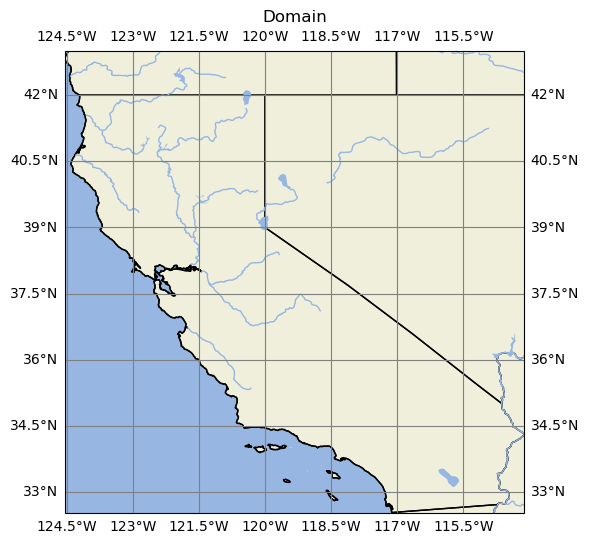

In [4]:
# Create a figure and axis with a specific projection
fig = plt.figure(figsize = (12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES)

# Set the extent of the map to the region of interest
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

# Add gridlines for latitude and longitude
ax.gridlines(draw_labels=True, color='gray')

# Add a title
plt.title('Domain')
plt.show()

:::{important}
The domain includes Nevada
:::

## Total Precipitation

In [5]:
tp = ds.tp # Selecting the variable
tp_cali = tp.sel(longitude=slice(lon1,lon2),latitude=slice(lat2,lat1)) # Selecting the area
tp_cali = tp_cali.mean(dim = ['longitude', 'latitude']) # Taking the grid mean
tp_cali

<xarray.DataArray 'tp' (valid_time: 752424)> Size: 3MB
dask.array<mean_agg-aggregate, shape=(752424,), dtype=float32, chunksize=(4320,), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-10-31T23:...
    number      int64 8B ...
    surface     float64 8B ...

### Timeseries Analysis

:::{note}
It takes a couple minutes to parse ERA5 data
:::

In [6]:
start_time = time.time() # For timing the output
precip = tp_cali.resample(valid_time='1D').sum().values # Taking daily data
dates = pd.date_range(start='1940-01-01', periods=len(precip), freq='D') # Taking daily dates for plotting
end_time = time.time()
t = end_time - start_time
print(f'{t} seconds')

91.88745069503784 seconds


In [7]:
# Converting from m to mm
precip = precip * 1000

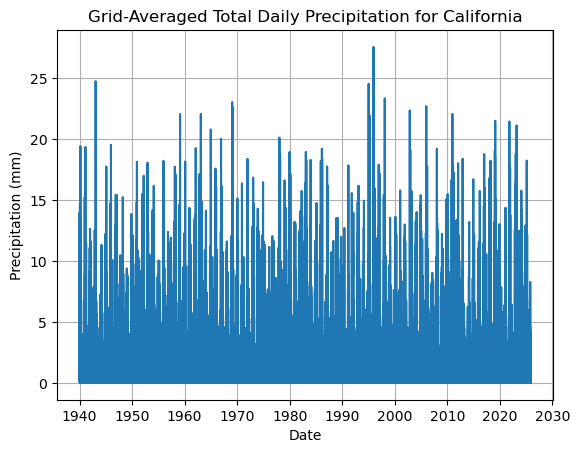

In [8]:
# Timeseries plot of daily precipitation
plt.plot(dates, precip)
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title('Grid-Averaged Total Daily Precipitation for California')
plt.grid()
plt.show()

It's hard to see any trends here. Let's try some other statitics.

### DataFrame Creation

:::{hint}
Pandas is your friend
:::

In [9]:
df = pd.DataFrame({'Date': dates, 'Precip DTotal': precip}) # Using the daily dates from the timeseries plot
df['Year'] = df['Date'].dt.year # Year column for splitting data in half
df

,Date,Precip DTotal,Year
0,1940-01-01,4.109561,1940
1,1940-01-02,9.943223,1940
2,1940-01-03,4.114964,1940
3,1940-01-04,11.560326,1940
4,1940-01-05,1.566564,1940
...,...,...,...
31346,2025-10-27,1.003714,2025
31347,2025-10-28,0.000224,2025
31348,2025-10-29,0.044414,2025
31349,2025-10-30,0.005414,2025


In [10]:
# Splitting the data in half
df_period_1 = df[(df['Year'] >= 1940) & (df['Year'] < 1982)]
df_period_2 = df[(df['Year'] >= 1983) & (df['Year'] < 2025)]

:::{hint}
Create changeable parameters for repeat analysis with different variables
:::

In [11]:
# Creating easily changeable parameters for repeat analysis
df_variable = 'Precip DTotal'
y_axis = 'Precipitation (mm)'
title_variable = 'Daily Total Precipitation (mm)'
data_period_1 = df_period_1[f'{df_variable}']
data_period_2 = df_period_2[f'{df_variable}']

### Boxplot Analysis

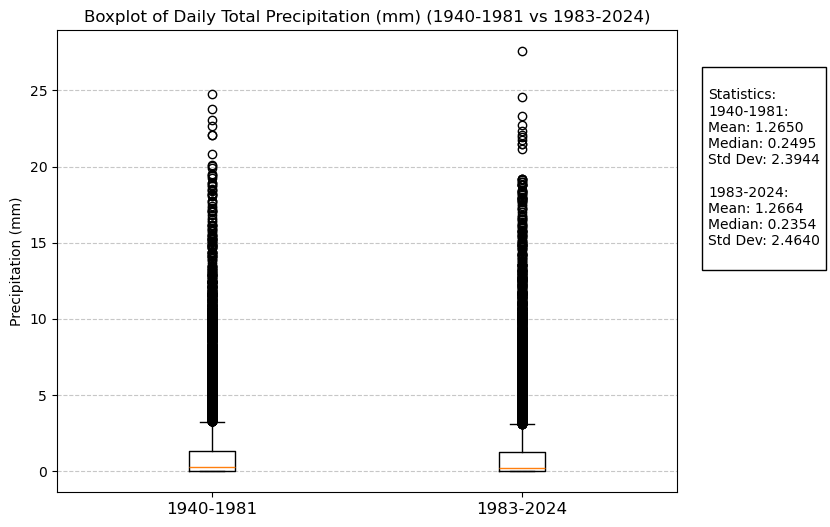

In [12]:
# Creating a boxplot of specific humidity values for the two time periods
plt.figure(figsize=(8, 6))
plt.boxplot([data_period_1,data_period_2])
plt.ylabel(f'{y_axis}')
plt.title(f'Boxplot of {title_variable} (1940-1981 vs 1983-2024)')
# Adding labels for the boxplots
plt.xticks([1, 2], ['1940-1981', '1983-2024'], fontsize=12)
# Adding gridlines for the specific humidity values
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Taking basic statistical values for showing on the plot and further use below
mean_period_1 = data_period_1.mean()
median_period_1 = data_period_1.median()
std_period_1 = data_period_1.std()

mean_period_2 = data_period_2.mean()
median_period_2 = data_period_2.median()
std_period_2 = data_period_2.std()

# Printing a text box on the figure
stats_text = f"""
Statistics:
1940-1981:
Mean: {mean_period_1:.4f}
Median: {median_period_1:.4f}
Std Dev: {std_period_1:.4f}

1983-2024:
Mean: {mean_period_2:.4f}
Median: {median_period_2:.4f}
Std Dev: {std_period_2:.4f}
"""
plt.gca().text(1.05,0.5, stats_text, 
                bbox=dict(facecolor='white', edgecolor='black'),
                transform=plt.gca().transAxes)
plt.show()

The means look similar, but there is a higher extreme value in period 2.

### Histogram and Probability Density Function (PDF)

:::{tip}
The PDF is generated from the mean and standard deviation of the data, which are taken using `Scipy.stats` `norm.fit`. `norm.pdf` generates the PDF using evenly-spaced x values.
:::

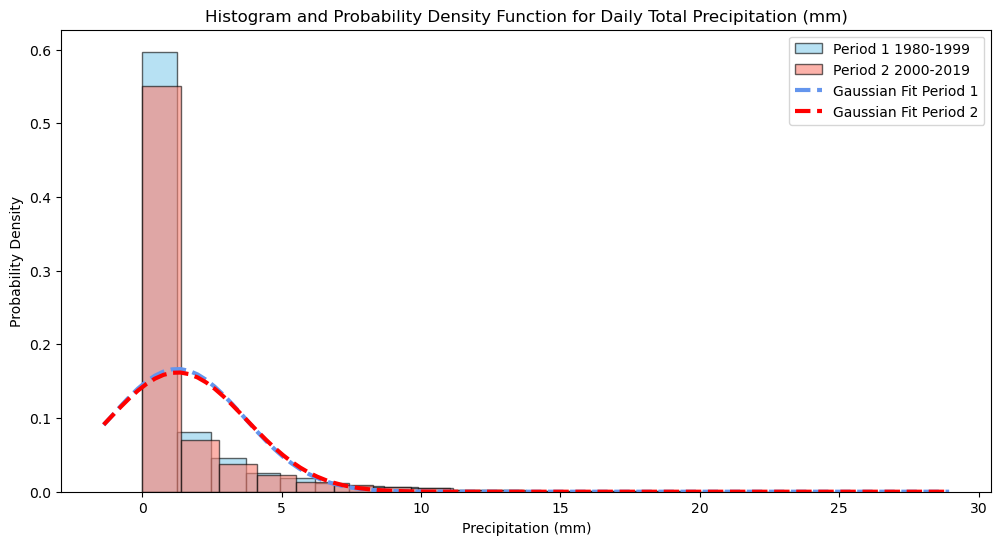

In [13]:
plt.figure(figsize=(12, 6)) 
plt.hist(data_period_1, bins=20, edgecolor='black', color='skyblue', alpha=0.6, label='Period 1 1980-1999', density=True)
plt.hist(data_period_2, bins=20, edgecolor='black', color='salmon', alpha=0.6, label='Period 2 2000-2019', density=True)

mu1, std1 = norm.fit(data_period_1)
x_min, x_max = plt.xlim() #finds the boundaries of the figure
# Creating evenly-spaced values for the PDF to be plotted on
x = np.linspace(x_min, x_max, 100) 
p1 = norm.pdf(x, mu1, std1) 
plt.plot(x, p1, color='cornflowerblue', linewidth=3, linestyle='--', label=f'Gaussian Fit Period 1') 

mu2, std2 = norm.fit(data_period_2) 
x = np.linspace(x_min, x_max, 100) 
p2 = norm.pdf(x, mu2, std2) 
plt.plot(x, p2, color='red', linewidth=3, linestyle='--', label=f'Gaussian Fit Period 2') 
plt.legend()
plt.title(f'Histogram and Probability Density Function for {title_variable}')
plt.xlabel(f'{y_axis}')
plt.ylabel('Probability Density')
plt.show()

It's hard to see any differences. The distribution is not well-modeled by the bell curve.

Going from the left to the right of the above plot, how quickly are values accumulated?

### Cumulative Distribution Function

:::{tip}
The CDF takes the same parameters as the PDF
:::

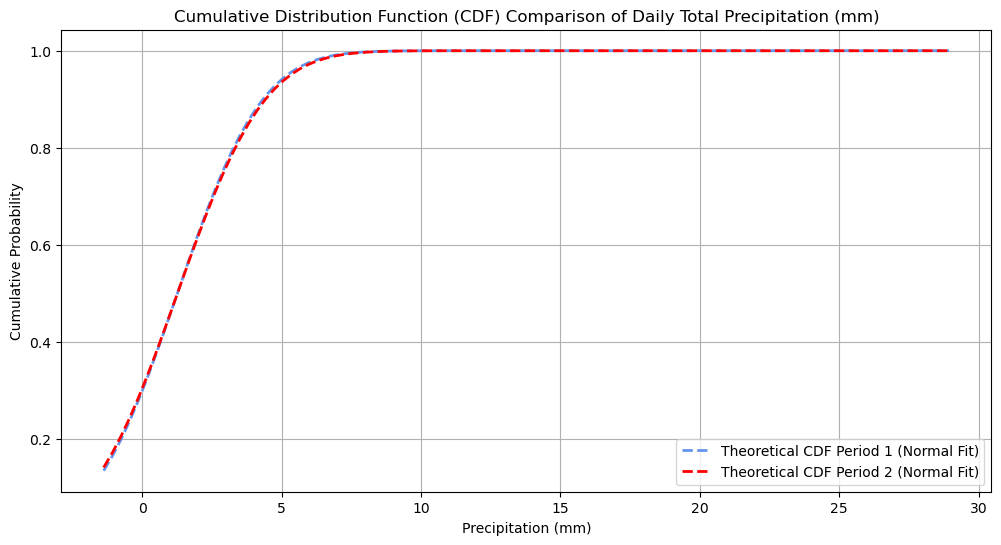

In [14]:
cdf1 = norm.cdf(x, mu1, std1)
cdf2 = norm.cdf(x, mu2, std2)
plt.figure(figsize=(12, 6))
plt.plot(x, cdf1, color='cornflowerblue', linestyle='--', linewidth=2, label='Theoretical CDF Period 1 (Normal Fit)')
plt.plot(x, cdf2, color='red', linestyle='--', linewidth=2, label='Theoretical CDF Period 2 (Normal Fit)')
plt.title(f'Cumulative Distribution Function (CDF) Comparison of {title_variable}')
plt.xlabel(f'{y_axis}')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid()
plt.show()

The CDFs look identical.

### Relative Risk

The following code compares exceedence rates of quantiles based on period 1 data. The relative risk is calculated for quantiles 1,2, .. 99, 99.9, 99.99, and 99.999.

In [15]:
# Making a list of quantiles to examine
quantiles = np.arange(1,100)
quantiles = np.append(quantiles,[99.9,99.99,99.999])
# Creating an empty list to append rr values to
rr_list = []
# Iterating over the quantiles
for i in quantiles:
    # Taking the quantile of period 1
    benchmark = np.percentile(data_period_1, i)
    # Summing the number of times that threshold is achieved in period 1
    count_ref = (data_period_1 > benchmark).sum()
    # Taking the total number of data points in period 1
    total_ref = len(data_period_1)
    # Taking the probability of achieving that threshold in period 1
    prob_ref = count_ref / total_ref

    # Repeating the analysis for period 2
    count_fut = (data_period_2 > benchmark).sum()
    total_fut = len(data_period_2)
    prob_fut = count_fut / total_fut

    # Taking the relative risk
    RR = prob_fut/prob_ref
    # Appending the value to the list
    rr_list.append(RR)

:::{note}
A horizontal line is plotted at y = 1 for the null hypothesis: RR = 1 refers to no change in exceedance rates.
:::

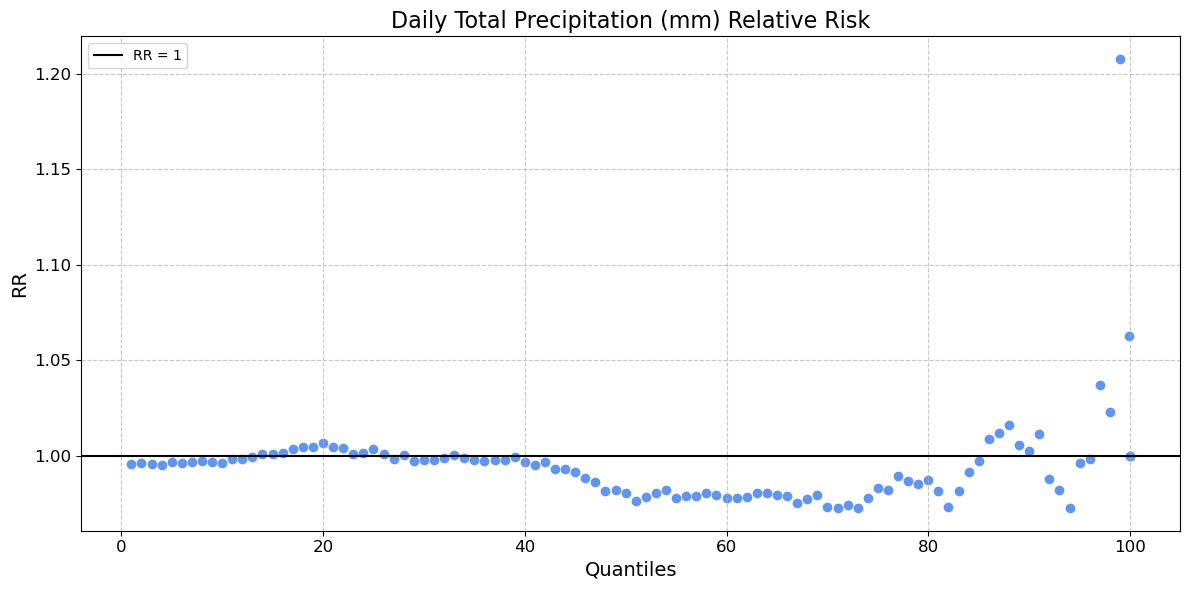

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(quantiles, rr_list, color='cornflowerblue')
plt.title(f'{title_variable} Relative Risk', fontsize=16)
plt.xlabel('Quantiles', fontsize=14)
plt.ylabel('RR', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(1, color='black', linestyle='-', label='RR = 1')
plt.tight_layout()
plt.legend()
plt.show()

RR values oscillate around 1 and increase at higher quantiles.

---

## Summary
It is difficult to find any trends in daily total precipitation for California. It appears that at extreme quantiles, it is more likely to get precipitation events in period 2.
### What's next?
Repeating the analysis for other variables

## Resources and references
This workflow was developed with my advisor, Dr. Timm, for analyzing thermodynamic variables associated with Hawaiian extreme precipitation. For this analysis, I changed the domain and instead of using the fraction of attributable risk (FAR) and odds ratio (OR), I used the relative risk (RR).